Training VAE with latent_dim=2...
Training VAE with latent_dim=5...
Training VAE with latent_dim=10...
Training VAE with latent_dim=20...
Training VAE with latent_dim=30...
Training VAE with latent_dim=40...


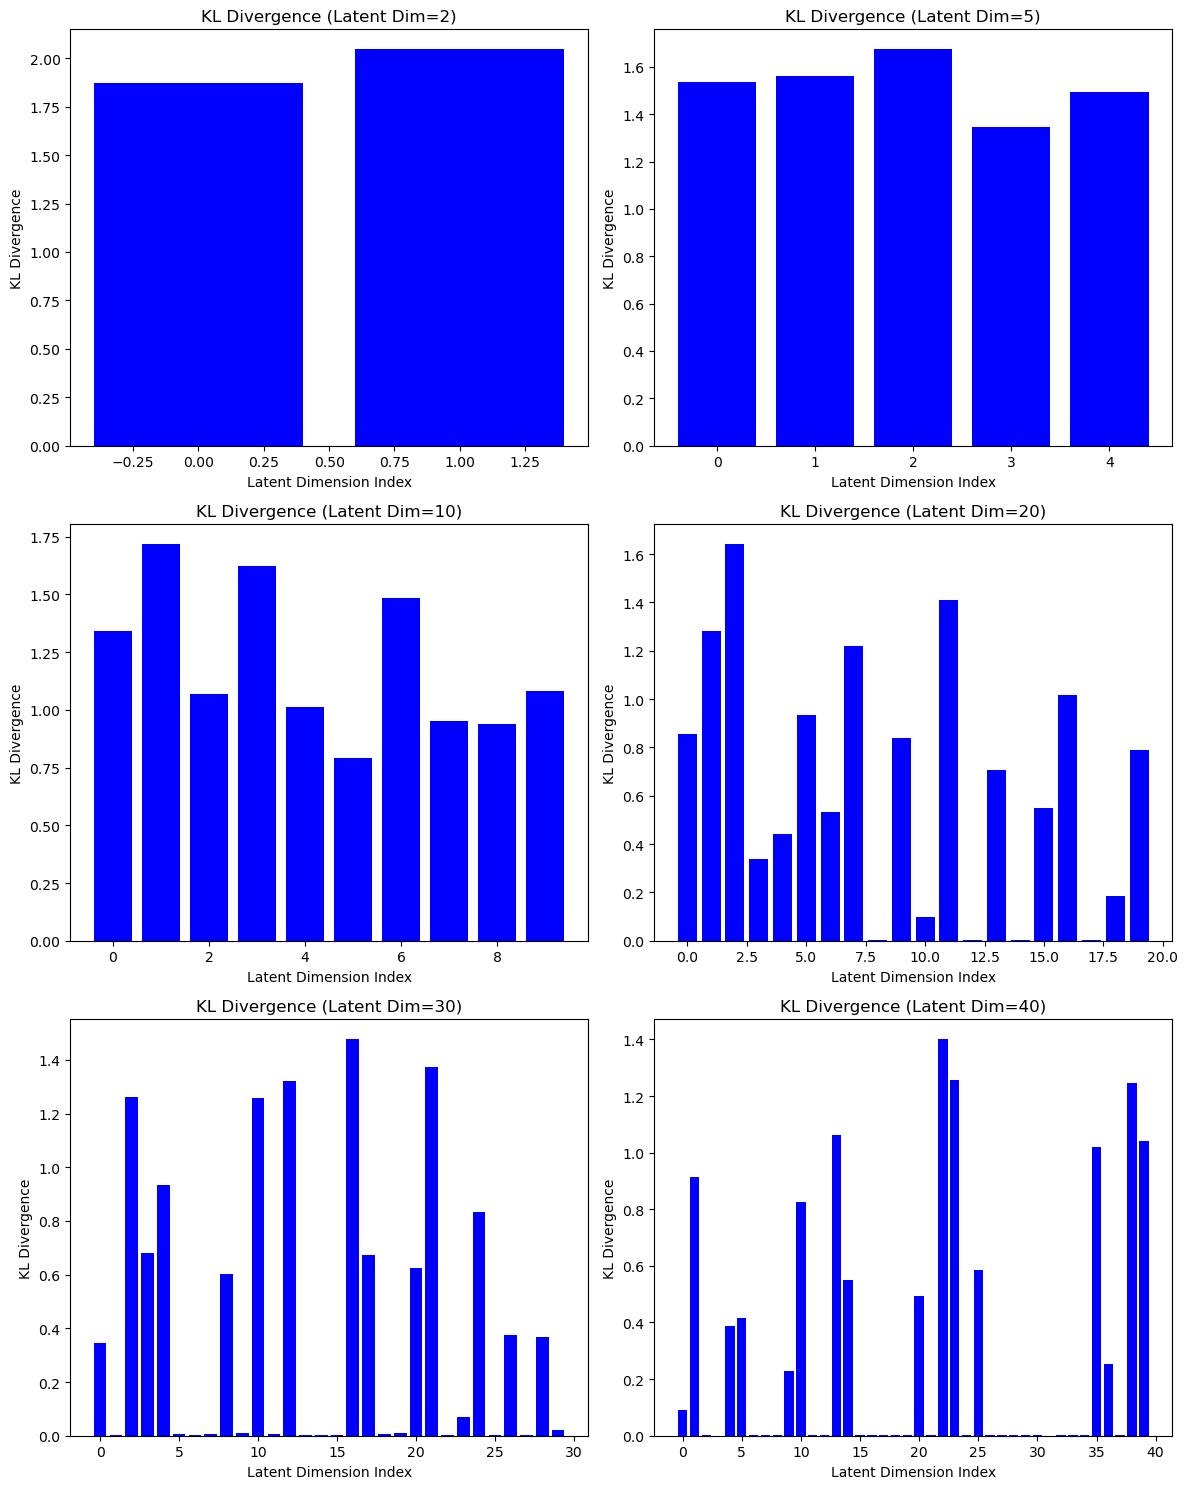

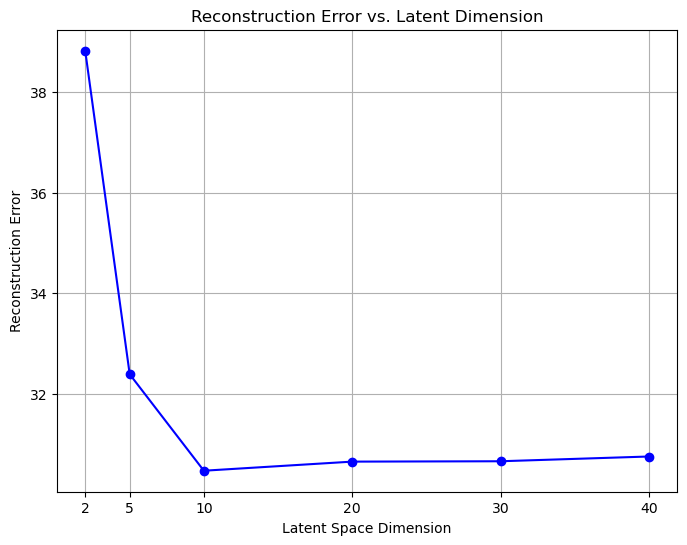

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1️⃣  加载 MNIST 数据集
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # 展平 28x28 = 784
train_data = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)

# 2️⃣  定义 VAE
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=10):
        super(VAE, self).__init__()
        # 编码器
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc2_logvar = nn.Linear(hidden_dim, latent_dim)

        # 解码器
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc2_mu(h)
        logvar = self.fc2_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))  # 输出范围在 0-1

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3️⃣  训练 VAE
def train_vae(latent_dim, num_epochs=10, beta=1.0):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    vae = VAE(latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(vae.parameters(), lr=0.001)

    vae.train()
    for epoch in range(num_epochs):
        total_loss = 0
        for batch in train_loader:
            x, _ = batch
            x = x.to(device)
            optimizer.zero_grad()
            recon_x, mu, logvar = vae(x)

            # 计算重构误差 (MSE)
            recon_loss = F.mse_loss(recon_x, x, reduction="sum")
            # 计算 KL 散度
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            # 总损失
            loss = recon_loss + beta * kl_loss

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    # 评估 KL 散度
    vae.eval()
    with torch.no_grad():
        mu, logvar = vae.encode(next(iter(train_loader))[0].to(device))
        kl_divergence = 0.5 * (torch.exp(logvar) + mu**2 - 1 - logvar)
        kl_values = kl_divergence.mean(dim=0).cpu().numpy()

    return total_loss / len(train_loader.dataset), kl_values  # 返回重构误差和 KL 散度向量

# 4️⃣  训练不同潜在空间维度的 VAE，并记录结果
latent_dims = [2, 5, 10, 20, 30, 40]
recon_errors = []
kl_distributions = []

for dim in latent_dims:
    print(f"Training VAE with latent_dim={dim}...")
    recon_error, kl_values = train_vae(latent_dim=dim)
    recon_errors.append(recon_error)
    kl_distributions.append(kl_values)

# 5️⃣ 可视化 KL 散度（6 张独立图，3 行 2 列）
fig, axes = plt.subplots(3, 2, figsize=(12, 15))  # 3 行 2 列
axes = axes.flatten()  # 展平以方便索引

for i, (dim, kl_values) in enumerate(zip(latent_dims, kl_distributions)):
    axes[i].bar(range(len(kl_values)), kl_values, color="blue")
    axes[i].set_xlabel("Latent Dimension Index")
    axes[i].set_ylabel("KL Divergence")
    axes[i].set_title(f"KL Divergence (Latent Dim={dim})")

plt.tight_layout()
plt.show()

# 6️⃣  绘制重构误差随潜在空间维度变化
plt.figure(figsize=(8, 6))
plt.plot(latent_dims, recon_errors, marker="o", linestyle="-", color="b")
plt.xlabel("Latent Space Dimension")
plt.ylabel("Reconstruction Error")
plt.title("Reconstruction Error vs. Latent Dimension")
plt.xticks(latent_dims)  # 让 X 轴显示整数
plt.grid()
plt.show()
